In [1]:
import os
import re
import sys
import yaml
import multiprocessing
import itertools

import pypsa

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes

import cartopy
import cartopy.io.shapereader as shpreader
import pycountry
import cartopy.crs as ccrs

sns.set_theme(style="whitegrid")

# Replace __file__ with the absolute path of the notebook file
notebook_path = "/home/koen/research/eu-hydrogen/notebooks/scratch.ipynb"

# Insert ../scripts/ to sys.path
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(notebook_path), '..', 'scripts')))

In [2]:
config_fn = "../config/eu-hydrogen.yaml"
config = yaml.safe_load(open(config_fn))

config_default = yaml.safe_load(open("../config/config.default.yaml"))

results_dir = "../results"

scenarios_fn = config["run"]["scenarios"]["file"]
scenarios = yaml.safe_load(open(os.path.join("..", scenarios_fn)))

use_cache = False

In [3]:
stat_names = [
    "h2prod",
    "imports",
    "system_cost",
    "obj_bound_dual",
    "h2price",
    "co2seq",
    "dac",
    "captured_co2",
    "elec_cap",
    "elec_cf",
    "total_onwind",
    "total_offwind",
    "total_solar",
]

def stats(n: pypsa.Network):
    # H2
    i = n.links.loc[n.links.carrier.isin(["H2 Electrolysis"])].index
    MWh_h2 = -(
        n.links_t.p1.loc[:, i].sum(axis=1) * n.snapshot_weightings.generators
    ).sum()
    h2prod = (MWh_h2 / 33.33) / 1e6

    # Imports
    i = n.generators.loc[n.generators.index.str.contains("green import")].index
    imports = (
        n.generators_t.p.loc[:, i].sum(axis=1) * n.snapshot_weightings.generators
    ).sum() / 1e6

    # System cost
    system_cost = n.statistics.capex().sum() + n.statistics.opex().sum()

    # System cost bound dual
    obj_bound_dual = (
        n.global_constraints.at["total_system_cost", "mu"]
        if "total_system_cost" in n.global_constraints.index
        else np.nan
    )

    # H2 price
    h2_buses = n.buses.index[n.buses.carrier == "H2"]
    h2price = (n.buses_t.marginal_price[h2_buses].mean(axis=1) * n.snapshot_weightings.generators).sum() / 8760

    # Total CO2 sequestration
    co2seq = n.stores.loc[n.stores.carrier == "co2 sequestered", "e_nom_opt"].sum()

    # Total amount of CO2 captured by DAC
    dac_i = n.links.loc[n.links.carrier == "DAC"].index
    dac = (
        n.links_t.p0.loc[:, dac_i].sum(axis=1) * n.snapshot_weightings.generators
    ).sum()

    # Total amount of CO2 captured, including industry, BECCS, etc.
    total = 0
    for i in [1, 2, 3, 4]:
        links_i = n.links.loc[n.links.__getattr__(f"bus{i}") == "co2 stored"].index
        co2 = n.links_t.__getattr__(f"p{i}").loc[:, links_i]
        co2 = co2.clip(upper=0)
        total -= (co2.sum(axis=1) * n.snapshot_weightings.generators).sum()

    captured_co2 = total / 1e6

    # Total installed capacity of electrolysers
    elec_i = n.links.loc[n.links.carrier == "H2 Electrolysis"].index
    elec_cap = n.links.loc[elec_i, "p_nom_opt"].sum()

    # Mean capacity factor of electrolysers
    if elec_cap > 0:
        elec_cf = (
            n.links_t.p0.loc[:, elec_i].sum(axis=1) * n.snapshot_weightings.generators
        ).sum() / (elec_cap * n.snapshot_weightings.generators.sum())
    else:
        elec_cf = np.nan

    # Total installed onshore wind
    total_onwind = n.generators.loc[n.generators.carrier == "onwind", "p_nom_opt"].sum()

    # Total installed offshore wind
    total_offwind = n.generators.loc[
        n.generators.carrier.isin(["offwind-ac", "offwind-dc", "offwind-float"]),
        "p_nom_opt",
    ].sum()

    # Total installed solar
    total_solar = n.generators.loc[n.generators.carrier == "solar", "p_nom_opt"].sum()

    return {
        "h2prod": h2prod,
        "imports": imports,
        "system_cost": system_cost,
        "obj_bound_dual": obj_bound_dual,
        "h2price": h2price,
        "co2seq": co2seq,
        "dac": dac,
        "captured_co2": captured_co2,
        "elec_cap": elec_cap,
        "elec_cf": elec_cf,
        "total_onwind": total_onwind,
        "total_offwind": total_offwind,
        "total_solar": total_solar,
    }

In [4]:
nets = {}

# Get the overall scenario names as the top level keys in scenarios dict
if config["run"]["name"] == "all":
    scenario_list = list(scenarios.keys())
else:
    scenario_list = [config["run"]["name"]]

# Assume that the following are uniquely defined for each run:
ll = config["scenario"]["ll"][0]
opts = config["scenario"]["opts"][0]

# The following are taken to vary for each run.
sector_opts = config["scenario"]["sector_opts"]
planning_horizons = config["scenario"]["planning_horizons"]
slacks = config["scenario"]["slack"]
senses = ["min", "max"]

# sector_opts = ["Ca-Ia-Ea-100seg", "Cb-Ia-Ea-100seg", "Cc-Ia-Ea-100seg"]

clusters = (45, 60)
resolution = ("500seg", None)

# If resolution not none, replace all instances of "\d+seg" with resolution in sector_opts
sector_opts = (
    [
        re.sub(r"\d+seg", resolution[0], s) if "seg" in s else s + "-" + resolution[0]
        for s in sector_opts
    ],
    sector_opts
)

def load_stats(file):
    return (
        stats(pypsa.Network(file))
        if os.path.exists(file)
        else {v: np.nan for v in stat_names}
    )

indexA = list(
    itertools.product(scenario_list, sector_opts[0], planning_horizons, slacks, senses)
)
index_optA = list(
    itertools.product(scenario_list, sector_opts[0], planning_horizons, [0], ["opt"])
)
indexB = list(
    itertools.product(scenario_list, sector_opts[1], planning_horizons, slacks, senses)
)
index_optB = list(
    itertools.product(scenario_list, sector_opts[1], planning_horizons, [0], ["opt"])
)

with multiprocessing.Pool(30) as pool:
    networksA = pool.map(
        load_stats,
        [
            f"{results_dir}/{s}/postnetworks/base_s_{clusters[0]}_l{ll}_{opts}_{o}_{h}_{sense}{slack}.nc"
            for s, o, h, slack, sense in indexA
        ],
    )
    networksB = pool.map(
        load_stats,
        [
            f"{results_dir}/{s}/postnetworks/base_s_{clusters[1]}_l{ll}_{opts}_{o}_{h}_{sense}{slack}.nc"
            for s, o, h, slack, sense in indexB
        ],
    )

    networksA.extend(
        pool.map(
            load_stats,
            [
                f"{results_dir}/{s}/postnetworks/base_s_{clusters[0]}_l{ll}_{opts}_{o}_{h}.nc"
                for s, o, h, _, _ in index_optA
            ],
        )
    )
    networksB.extend(
        pool.map(
            load_stats,
            [
                f"{results_dir}/{s}/postnetworks/base_s_{clusters[1]}_l{ll}_{opts}_{o}_{h}.nc"
                for s, o, h, _, _ in index_optB
            ],
        )
    )

networksA = dict(zip(indexA + index_optA, networksA))
networksB = dict(zip(indexB + index_optB, networksB))

/fp/homes01/u01/ec-koenvg/.conda/envs/my_base/envs/eu-hydrogen-new/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=645354) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/fp/homes01/u01/ec-koenvg/.conda/envs/my_base/envs/eu-hydrogen-new/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=645354) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/fp/homes01/u01/ec-koenvg/.conda/envs/my_base/envs/eu-hydrogen-new/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=645354) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/fp/homes01/u01/ec-koenvg/.conda/envs/my_base/envs/eu-hydrogen-new/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=645354) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.

/fp/homes01/u01/ec-koenvg/.conda/envs/my_base/envs/eu-hydrogen-new/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=645354) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/fp/homes01/u01/ec-koenvg/.conda/envs/my_base/envs/eu-hydrogen-new/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=645354) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/fp/homes01/u01/ec-koenvg/.conda/envs/my_base/envs/eu-hydrogen-new/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=645354) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/fp/homes01/u01/ec-koenvg/.conda/envs/my_base/envs/eu-hydrogen-new/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=645354) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.

In [5]:
dfs = []
for networks in [networksA, networksB]:
    df = pd.DataFrame(networks).T.reset_index()
    df.columns = ["scenario", "opts", "horizon", "slack", "sense"] + stat_names

    # Split the "scenario" column into "year" and "biomass"; has format "Y<year>_B<biomass_flag>"
    df[["year", "B"]] = df["scenario"].str.extract(r"Y(\d+)_B([a-z])")

    # Drop the "scenario" column
    df.drop(columns=["scenario"], inplace=True)

    # Strip any suffix of the form "-\d+seg" from the "opts" column
    df["opts"] = df["opts"].str.replace(r"-\d+seg", "", regex=True)

    # The "opts" column has the form "XX-YY-ZZ-..."; we want to split this into separate columns and keep only the last character
    flags = list(map(lambda s: s[0], df.at[0, "opts"].split("-")))
    df[flags] = df["opts"].str.split("-", expand=True).map(lambda s: s[-1])
    df.drop(columns=["opts"], inplace=True)

    # Add a column concatenating the year and flags
    df["scenario"] = df["year"] + df["B"] + df[flags].apply(lambda x: "".join(x), axis=1)

    # Now set the index to the scenario, year, flags, slack and horizon
    df.set_index(["scenario", "year", "B"] + flags + ["sense", "slack", "horizon"], inplace=True)

    dfs.append(df)

    display(df)

h2prod       imports  \
scenario year B C I E sense slack horizon                               
1987aaaa 1987 a a a a min   0.02  2025    -0.000000e+00  5.166565e-11   
                      max   0.02  2025     3.842324e+00  4.985136e-07   
                      min   0.05  2025    -0.000000e+00  3.845466e-11   
                      max   0.05  2025     9.252381e+00  3.276225e-08   
                      min   0.10  2025    -0.000000e+00  3.654210e-11   
...                                                 ...           ...   
2020ccbb 2020 c c b b opt   0.00  2030     2.796928e-08  2.628086e-06   
                                  2035     3.982293e-08  3.163159e-06   
                                  2040     3.993038e+00  1.782647e+02   
                                  2045     3.075374e+00  1.141760e+02   
                                  2050     2.972675e+00  2.317123e+02   

                                            system_cost  obj_bound_dual  \
scenario year B C I E sense slack horizon                                 
1987aaaa 1987 a a a a min   0.02  2025     9.863919e+11             NaN   
                      max   0.02  2025     1.001188e+12      -14.392935   
                      min   0.05  2025     9.863919e+11             NaN   
                      max   0.05  2025     1.023382e+12      -13.150271   
                      min   0.10  2025     9.863919e+11             NaN   
...                                                 ...             ...   
2020ccbb 2020 c c b b opt   0.00  2030     8.602348e+11             NaN   
                                  2035     7.520245e+11             NaN   
                                  2040     7.490586e+11             NaN   
                                  2045     6.956554e+11             NaN   
                                  2050     6.476197e+11             NaN   

                                             h2price        co2seq       dac  \
scenario year B C I E sense slack horizon                                      
1987aaaa 1987 a a a a min   0.02  2025     61.215071  0.000000e+00  0.258292   
                      max   0.02  2025      0.873237  1.426963e+00  0.101345   
                      min   0.05  2025     61.217366  0.000000e+00  0.291903   
                      max   0.05  2025      0.697509 -2.399591e-01  0.006660   
                      min   0.10  2025     61.223550  0.000000e+00  0.199373   
...                                              ...           ...       ...   
2020ccbb 2020 c c b b opt   0.00  2030     55.567675  1.415063e+07  0.326931   
                                  2035     62.654816  3.000000e+08  0.322282   
                                  2040     85.778118  5.000000e+08  0.476078   
                                  2045     63.031487  5.909462e+08  0.058851   
                                  2050     61.981790  6.056690e+08  0.086068   

                                           captured_co2      elec_cap  \
scenario year B C I E sense slack horizon                               
1987aaaa 1987 a a a a min   0.02  2025         7.159741      0.000000   
                      max   0.02  2025         7.159741  24892.976251   
                      min   0.05  2025         7.159741      0.000000   
                      max   0.05  2025         7.159740  59941.499193   
                      min   0.10  2025         7.159741      0.000000   
...                                                 ...           ...   
2020ccbb 2020 c c b b opt   0.00  2030        21.310370      0.000674   
                                  2035       307.159741      0.000829   
                                  2040       507.159741  48930.120673   
                                  2045       598.105982  48930.074298   
                                  2050       612.828707  48930.074503   

                                            elec_cf   total_onwind  \
scenario year B C I E sense slack horizon                     

h2prod       imports  \
scenario year B C I E sense slack horizon                               
1987aaaa 1987 a a a a min   0.02  2025    -0.000000e+00  1.339833e-11   
                      max   0.02  2025     3.826693e+00  2.522496e-06   
                      min   0.05  2025    -0.000000e+00  1.510578e-10   
                      max   0.05  2025     9.192619e+00  1.988053e-06   
                      min   0.10  2025    -0.000000e+00  1.612746e-11   
...                                                 ...           ...   
2020ccbb 2020 c c b b opt   0.00  2030     4.089872e-07  3.859447e-05   
                                  2035     7.173636e-07  6.402206e-05   
                                  2040     3.900898e+00  1.918637e+02   
                                  2045     2.826021e+00  1.564010e+02   
                                  2050     2.773519e+00  2.674769e+02   

                                            system_cost  obj_bound_dual  \
scenario year B C I E sense slack horizon                                 
1987aaaa 1987 a a a a min   0.02  2025     9.916882e+11             NaN   
                      max   0.02  2025     1.006486e+12      -14.336675   
                      min   0.05  2025     9.917209e+11             NaN   
                      max   0.05  2025     1.028798e+12      -12.822516   
                      min   0.10  2025     9.916963e+11             NaN   
...                                                 ...             ...   
2020ccbb 2020 c c b b opt   0.00  2030     8.710108e+11             NaN   
                                  2035     7.677598e+11             NaN   
                                  2040     7.682463e+11             NaN   
                                  2045     7.098399e+11             NaN   
                                  2050     6.597403e+11             NaN   

                                             h2price        co2seq       dac  \
scenario year B C I E sense slack horizon                                      
1987aaaa 1987 a a a a min   0.02  2025     61.309104  0.000000e+00  0.317351   
                      max   0.02  2025      0.873124 -6.684026e+00  0.290461   
                      min   0.05  2025     61.313078  0.000000e+00  3.449233   
                      max   0.05  2025      0.654379  1.317182e+01  0.280631   
                      min   0.10  2025     61.310771  0.000000e+00  0.312651   
...                                              ...           ...       ...   
2020ccbb 2020 c c b b opt   0.00  2030     55.741511  4.135666e+07  4.665380   
                                  2035     65.880375  3.000000e+08  5.676082   
                                  2040     87.659478  5.000000e+08  0.488600   
                                  2045     62.915585  5.834830e+08  0.678969   
                                  2050     62.009871  5.983340e+08  0.153208   

                                           captured_co2      elec_cap  \
scenario year B C I E sense slack horizon                               
1987aaaa 1987 a a a a min   0.02  2025         7.154781      0.000000   
                      max   0.02  2025         7.154781  24795.372772   
                      min   0.05  2025         7.154791      0.000000   
                      max   0.05  2025         7.154782  59556.641347   
                      min   0.10  2025         7.154781      0.000000   
...                                                 ...           ...   
2020ccbb 2020 c c b b opt   0.00  2030        48.511454      0.009334   
                                  2035       307.154791      0.014748   
                                  2040       507.154781  47542.043473   
                                  2045       590.637758  47542.033120   
                                  2050       605.488775  47542.032197   

                                            elec_cf   total_onwind  \
scenario year B C I E sense slack horizon                     

In [6]:
diff = dfs[1].sub(dfs[0])

In [7]:
diff

h2prod       imports  \
scenario year B C I E sense slack horizon                               
1987aaaa 1987 a a a a min   0.02  2025     0.000000e+00 -3.826732e-11   
                      max   0.02  2025    -1.563146e-02  2.023982e-06   
                      min   0.05  2025     0.000000e+00  1.126031e-10   
                      max   0.05  2025    -5.976188e-02  1.955290e-06   
                      min   0.10  2025     0.000000e+00 -2.041463e-11   
...                                                 ...           ...   
2020ccbb 2020 c c b b opt   0.00  2030     3.810179e-07  3.596638e-05   
                                  2035     6.775406e-07  6.085891e-05   
                                  2040    -9.213994e-02  1.359901e+01   
                                  2045    -2.493531e-01  4.222501e+01   
                                  2050    -1.991567e-01  3.576457e+01   

                                            system_cost  obj_bound_dual  \
scenario year B C I E sense slack horizon                                 
1987aaaa 1987 a a a a min   0.02  2025     5.296327e+09             NaN   
                      max   0.02  2025     5.298626e+09        0.056260   
                      min   0.05  2025     5.328985e+09             NaN   
                      max   0.05  2025     5.416083e+09        0.327755   
                      min   0.10  2025     5.304414e+09             NaN   
...                                                 ...             ...   
2020ccbb 2020 c c b b opt   0.00  2030     1.077604e+10             NaN   
                                  2035     1.573529e+10             NaN   
                                  2040     1.918773e+10             NaN   
                                  2045     1.418445e+10             NaN   
                                  2050     1.212053e+10             NaN   

                                            h2price        co2seq       dac  \
scenario year B C I E sense slack horizon                                     
1987aaaa 1987 a a a a min   0.02  2025     0.094033  0.000000e+00  0.059059   
                      max   0.02  2025    -0.000114 -8.110989e+00  0.189117   
                      min   0.05  2025     0.095712  0.000000e+00  3.157330   
                      max   0.05  2025    -0.043129  1.341178e+01  0.273971   
                      min   0.10  2025     0.087221  0.000000e+00  0.113278   
...                                             ...           ...       ...   
2020ccbb 2020 c c b b opt   0.00  2030     0.173836  2.720603e+07  4.338449   
                                  2035     3.225559  1.273334e-03  5.353800   
                                  2040     1.881360 -2.360344e-04  0.012521   
                                  2045    -0.115902 -7.463264e+06  0.620118   
                                  2050     0.028081 -7.334972e+06  0.067140   

                                           captured_co2     elec_cap  \
scenario year B C I E sense slack horizon                              
1987aaaa 1987 a a a a min   0.02  2025        -0.004960     0.000000   
                      max   0.02  2025        -0.004959   -97.603480   
                      min   0.05  2025        -0.004950     0.000000   
                      max   0.05  2025        -0.004958  -384.857846   
                      min   0.10  2025        -0.004960     0.000000   
...                                                 ...          ...   
2020ccbb 2020 c c b b opt   0.00  2030        27.201084     0.008660   
                                  2035        -0.004949     0.013919   
                                  2040        -0.004960 -1388.077201   
                                  2045        -7.468224 -1388.041178   
                                  2050        -7.339932 -1388.042306   

                                            elec_cf  total_onwind  \
scenario year B C I E sense slack horizon                           
1987aaaa 1987 a a a 

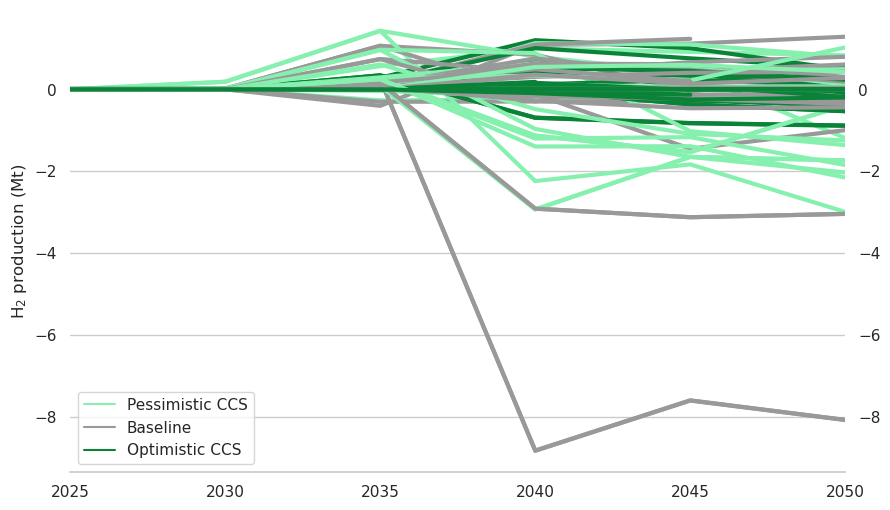

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

df_slacksize = diff.copy()
# Map values in "slack" index level to 0.1 - "slack"
df_slacksize.reset_index("slack", inplace=True)
df_slacksize["slack"] = 0.1 - df_slacksize["slack"]
df_slacksize.set_index("slack", append=True, inplace=True)

palette = {"a": "#86f0af", "b": "#999999", "c": "#0a8339"}

for s in df.index.get_level_values("scenario").unique():
    sense = "opt"
    sns.lineplot(
        data=df_slacksize.xs(s, level="scenario").xs(sense, level="sense"),
        x="horizon",
        y="h2prod",
        hue="C",
        palette=palette,
        linewidth=3,
        ax=ax,
    )

# Increase zorder of all "opt" lines
# for line in ax.lines:
#     # Recognise by colour
#     if line.get_color() == palette["opt"]:
#         line.set_zorder(10)

ax.set_xlim(2025, 2050)

# Turn off x-grid
ax.xaxis.grid(False)

# Turn off spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Duplicate y ticks on right
ax.yaxis.set_tick_params(labelright=True)

# Set labels
ax.set_ylabel("H$_2$ production (Mt)")
ax.set_xlabel(None)

# Manually ad a legend with one entry for each pallete color
pretty_names = {"a": "Pessimistic CCS", "b": "Baseline", "c": "Optimistic CCS"}
handles = [
    plt.Line2D([0], [0], color=palette[k], label=pretty_names[k]) for k in palette
]
ax.legend(handles=handles, loc="lower left")

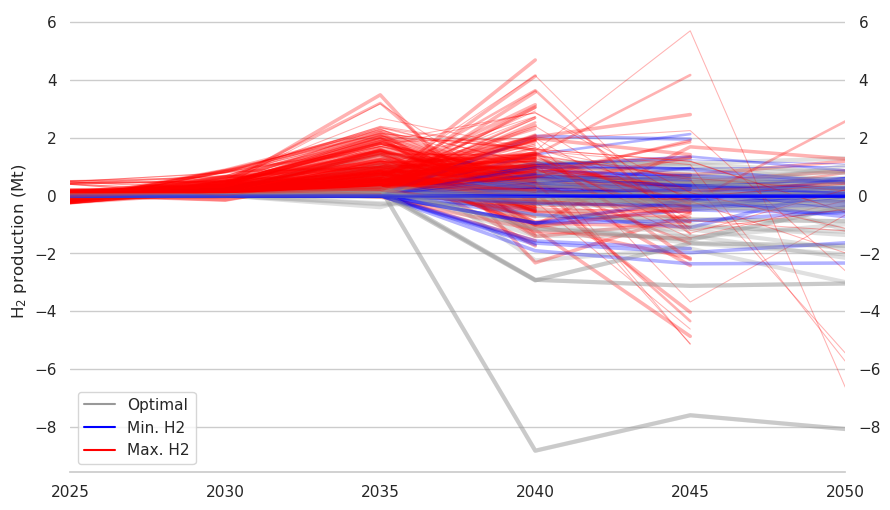

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

df_slacksize = diff.copy()
# Map values in "slack" index level to 0.1 - "slack"
df_slacksize.reset_index("slack", inplace=True)
df_slacksize["slack"] = 0.1 - df_slacksize["slack"]
df_slacksize.set_index("slack", append=True, inplace=True)

palette = {"opt": "#999999", "min": "blue", "max": "red"}

for s in df.index.get_level_values("scenario").unique():
    sns.lineplot(
        data=df_slacksize.xs(s, level="scenario"),
        x="horizon",
        y="h2prod",
        hue="sense",
        size="slack",
        palette=palette,
        alpha=0.3,
        ax=ax,
    )

# Increase zorder of all "opt" lines
# for line in ax.lines:
#     # Recognise by colour
#     if line.get_color() == palette["opt"]:
#         line.set_zorder(10)

ax.set_xlim(2025, 2050)

# Turn off x-grid
ax.xaxis.grid(False)

# Turn off spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Duplicate y ticks on right
ax.yaxis.set_tick_params(labelright=True)

# Set labels
ax.set_ylabel("H$_2$ production (Mt)")
ax.set_xlabel(None)

# Manually ad a legend with one entry for each pallete color
pretty_names = {"opt": "Optimal", "min": "Min. H2", "max": "Max. H2"}
handles = [
    plt.Line2D([0], [0], color=palette[k], label=pretty_names[k]) for k in palette
]
ax.legend(handles=handles, loc="lower left")

In [10]:
diff.h2prod.abs().mean()

0.36863612005708235